# L3 · Notebook 02 — γ 改变最优策略

## 教学目标

γ 是"耐心程度"参数：
- γ → 0：智能体只看眼前奖励 → 短视
- γ → 1：考虑无穷远未来 → 远视

**重点论断**：γ 不仅影响 $v^*$ 的尺度，还可能改变 $\pi^*$ 本身。

本 notebook 跑 4 个 γ 值，并排画 $V^*$ 和 $\pi^*$。

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from shared.grid_world import GridWorld, GridConfig
from shared.plotting import plot_value_heatmap, plot_policy_arrows, setup_chinese_font

setup_chinese_font()

'Heiti TC'

## 1. 4 组 γ 都跑一遍 VI

In [2]:
gammas = [0.1, 0.5, 0.9, 0.99]
results = {}
for g in gammas:
    env = GridWorld(GridConfig(gamma=g))
    V_star, pi_star, res = env.value_iteration(tol=1e-10)
    results[g] = (env, V_star, pi_star, len(res))
    print(f'γ={g:>5}: VI {len(res):>4} 轮收敛, V*[s1]={V_star[0]:+.4f}, V*[mean]={V_star.mean():+.4f}')

γ=  0.1: VI   10 轮收敛, V*[s1]=+0.0000, V*[mean]=+0.1689
γ=  0.5: VI   10 轮收敛, V*[s1]=+0.0156, V*[mean]=+0.2436
γ=  0.9: VI   10 轮收敛, V*[s1]=+0.5314, V*[mean]=+0.6617
γ= 0.99: VI   10 轮收敛, V*[s1]=+0.9415, V*[mean]=+0.9236


## 2. 4 张 V* 热图并排（统一颜色尺度看尺度差异）

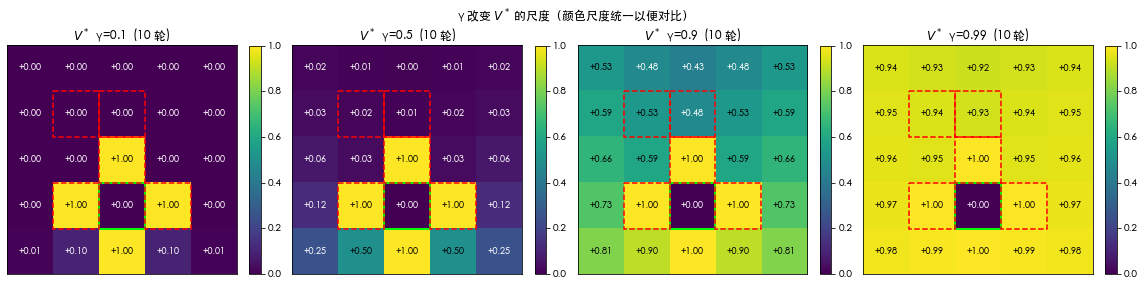

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
vmin = min(r[1].min() for r in results.values())
vmax = max(r[1].max() for r in results.values())
for ax, (g, (env, V, pi, k)) in zip(axes, results.items()):
    plot_value_heatmap(env, V, ax=ax, title=f'$V^*$  γ={g}  ({k} 轮)', vmin=vmin, vmax=vmax)
fig.suptitle('γ 改变 $V^*$ 的尺度（颜色尺度统一以便对比）')
plt.tight_layout()
plt.savefig('figures/gamma_V_star.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. 4 张 π* 箭头图并排

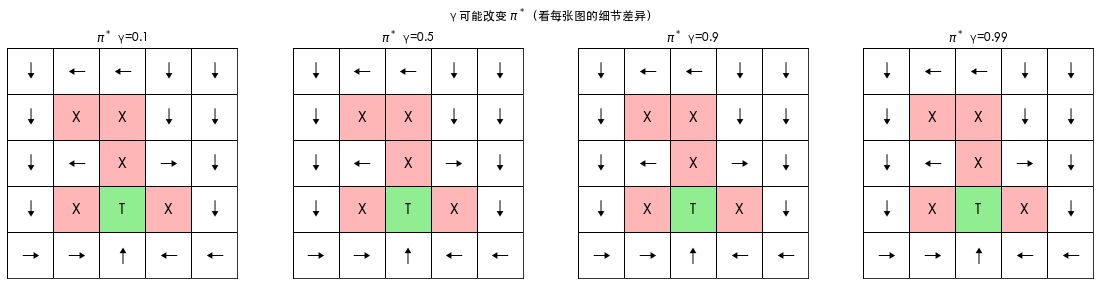

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (g, (env, V, pi, k)) in zip(axes, results.items()):
    plot_policy_arrows(env, pi, ax=ax, title=f'$\\pi^*$  γ={g}')
fig.suptitle('γ 可能改变 $\\pi^*$（看每张图的细节差异）')
plt.tight_layout()
plt.savefig('figures/gamma_pi_star.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. 找出策略不一致的状态

In [5]:
ref_env, _, ref_pi, _ = results[0.9]
diffs = {g: [] for g in gammas if g != 0.9}
for g, (_, _, pi, _) in results.items():
    if g == 0.9:
        continue
    for s in ref_env.all_states():
        if pi[s] != ref_pi[s]:
            diffs[g].append((ref_env.display_index(s), ref_pi[s], pi[s]))

for g, ds in diffs.items():
    print(f'γ={g} vs γ=0.9：{len(ds)} 个状态策略不同')
    for s_i, a_ref, a_g in ds[:8]:
        print(f'  s{s_i}: γ=0.9 选 "{a_ref}"  →  γ={g} 选 "{a_g}"')
    if len(ds) > 8:
        print(f'  ... ({len(ds)-8} more)')
    print()

γ=0.1 vs γ=0.9：0 个状态策略不同

γ=0.5 vs γ=0.9：0 个状态策略不同

γ=0.99 vs γ=0.9：0 个状态策略不同



## 5. 经典案例：穿过禁区 vs 绕路

对某些 γ，从某个状态出发，最优策略可能选择**穿过 forbidden 吃 -1**（因为绕路代价更大），但 γ 较小时反而绕路。

构造一个能放大这个现象的特殊布局：

In [6]:
# 在 (0,2) 设置 forbidden barrier；目标在 (0,4)
# 从 (0,0) 出发，要么穿 (0,2) 吃 -1（路径短），要么绕到第二行（路径长）
cfg = GridConfig(
    n_rows=2, n_cols=5,
    target=(0, 4),
    forbidden=((0, 2),),
    r_step=0.0, gamma=0.9,
)

for g in [0.5, 0.9]:
    cfg2 = GridConfig(**{**cfg.__dict__, 'gamma': g})
    env = GridWorld(cfg2)
    V, pi, _ = env.value_iteration()
    print(f'γ={g}:')
    print('  V[s1]={:+.4f},  V[s5]={:+.4f}'.format(V[0], V[4]))
    print('  策略 (5×2 网格)：')
    for r in range(env.cfg.n_rows):
        line = ''
        for c in range(env.cfg.n_cols):
            arrow = {'up': '↑', 'down': '↓', 'left': '←', 'right': '→', 'stay': '·'}
            if (r, c) == env.cfg.target:
                line += ' T '
            elif (r, c) in env.cfg.forbidden:
                line += ' X '
            else:
                line += ' ' + arrow[pi[(r, c)]] + ' '
        print('    ' + line)
    print()

γ=0.5:
  V[s1]=+0.0312,  V[s5]=+0.0000
  策略 (5×2 网格)：
     ↓  ↓  X  →  T 
     →  →  →  ↑  ↑ 

γ=0.9:
  V[s1]=+0.5905,  V[s5]=+0.0000
  策略 (5×2 网格)：
     ↓  ↓  X  →  T 
     →  →  →  ↑  ↑ 



## 6. 课堂诊断小结

| 论断 | 数值 |
|---|---|
| γ 影响 V* 尺度 | γ=0.1 时 V* 极小；γ=0.99 时 V* 较大 |
| γ 影响收敛速度 | γ=0.1: 几轮; γ=0.99: 数百轮 |
| γ 可改变 π* | 表中每个不同的 (s, a_ref → a_γ) |
| 短视 vs 远视的策略哲学 | γ 小：路径越短越好；γ 大：避免负奖励 |

## 思考题

1. 真实任务中 γ 应当怎么选？给出几个常见经验值（CartPole 用 0.99，Atari 用 0.99，象棋会怎样？）
2. 如果同时改 r_step（每步代价）和 γ，二者的效果可能等价吗？（提示：折现 vs 步数惩罚）
3. 如果 γ=1 + 终止状态吸收 + 所有状态都能到终止，最优策略仍存在吗？